# spacv guide — version 2

A complete, reproducible tour of the public cross-validation API: `HBLOCK`,
`SKCV` (including spatial leave-one-out), `RepeatedSKCV`, `UserDefinedSCV`, and
all eight `STCV` modes. Each configuration is iterated **to exhaustion**, checked,
and used to fit and evaluate a regression model on every fold.

The 2.5D views place eastings and northings on the horizontal plane and elapsed
time on the vertical axis. Height represents time, not terrain or the target.
Static previews and an interactive method/fold selector show training, test,
and buffer-excluded observations using the actual split indices.

Run all cells from the repository root. This notebook generates its own small
projected dataset, so it needs no downloaded examples or absolute data paths.
Install the checkout with `python -m pip install -e .` and notebook support with
`python -m pip install jupyter ipykernel`. Select that Python environment in Jupyter.
The original `spacv_guide.ipynb` is retained separately.


In [1]:
%matplotlib inline
import json
import platform
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import HTML, display
from shapely.geometry import box
from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import spacv

SEED = 42
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})
display(pd.Series({'Python': platform.python_version(), 'spacv': spacv.__version__,
                   'numpy': np.__version__, 'pandas': pd.__version__,
                   'geopandas': gpd.__version__, 'sklearn': sklearn.__version__},
                  name='Execution environment'))


Python       3.14.8
spacv        0.0.25
numpy         2.5.3
pandas        3.0.6
geopandas     1.2.0
sklearn       1.9.1
Name: Execution environment, dtype: str

## 1. A small station × time panel

Twelve stations are sampled at four irregular times, including two readings
one hour apart. Two additional observations duplicate station-time pairs so
`lolto` and row-wise `loo` have visibly different fold counts. Coordinates are
synthetic metres in a projected CRS; buffer radii use those same units.

Locations are exact coordinate pairs. Round or snap jittered station coordinates
before grouping real data. Temporal modes require numeric or datetime columns.
All model features are numeric; geometry and timestamps are supplied to the
splitters separately. `.iloc` consumes the returned **positional** indices.


In [2]:
rng = np.random.default_rng(SEED)
sx, sy = np.meshgrid([100., 350., 600., 850.], [100., 400., 700.])
stations = pd.DataFrame({'station': np.arange(sx.size),
                         'east': sx.ravel(), 'north': sy.ravel()})
dates = pd.to_datetime(['2024-01-01 00:00', '2024-01-01 01:00',
                        '2024-01-05 00:00', '2024-02-01 00:00'])
rows = stations.loc[stations.index.repeat(len(dates))].reset_index(drop=True)
rows['timestamp'] = np.tile(dates, len(stations))
rows = pd.concat([rows, rows.iloc[[0, 9]]], ignore_index=True)
rows['days'] = (rows.timestamp - dates.min()).dt.total_seconds() / 86400
rows['block'] = (rows.east >= 475).astype(int) + 2 * (rows.north >= 375).astype(int)
rows['terrain'] = np.sin(rows.east / 230) + np.cos(rows.north / 310)
rows['temperature'] = 10 + .12 * rows.days + .003 * rows.east + rng.normal(0, .5, len(rows))
station_effect = rng.normal(0, 1, len(stations))
rows['target'] = (3 * rows.terrain + 1.7 * rows.temperature + .08 * rows.days
                  + station_effect[rows.station] + rng.normal(0, .3, len(rows)))
panel = gpd.GeoDataFrame(rows, geometry=gpd.points_from_xy(
    500000 + rows.east, 5700000 + rows.north), crs='EPSG:32630')
feature_cols = ['terrain', 'temperature', 'days']
X, y = panel[feature_cols], panel.target
model = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
display(panel.drop(columns='geometry').head())
print(f'{len(panel)} observations, {panel.station.nunique()} locations, '
      f'{panel.timestamp.nunique()} times, CRS: {panel.crs}')


,station,east,north,timestamp,days,block,terrain,temperature,target
0,0,100.0,100.0,2024-01-01 00:00:00,0.000000,0,1.369634,10.452359,22.215856
1,0,100.0,100.0,2024-01-01 01:00:00,0.041667,0,1.369634,9.785008,21.211734
2,0,100.0,100.0,2024-01-05 00:00:00,4.000000,0,1.369634,11.155226,23.895272
3,0,100.0,100.0,2024-02-01 00:00:00,31.000000,0,1.369634,14.490282,31.749505
4,1,350.0,100.0,2024-01-01 00:00:00,0.000000,0,1.947217,10.074482,23.494943


50 observations, 12 locations, 4 times, CRS: EPSG:32630


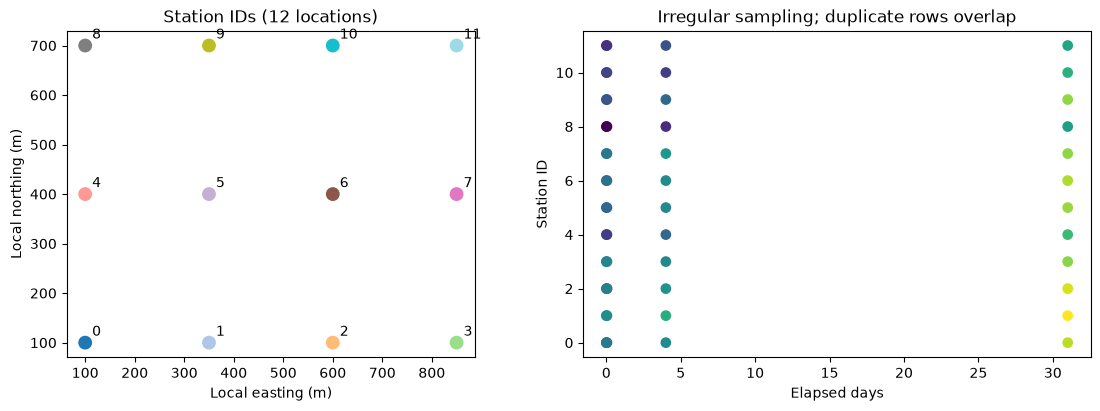

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].scatter(stations.east, stations.north, c=np.arange(len(stations)), cmap='tab20', s=80)
for site in stations.itertuples():
    axes[0].annotate(str(site.station), (site.east, site.north), xytext=(5, 5), textcoords='offset points')
axes[0].set(title='Station IDs (12 locations)', xlabel='Local easting (m)', ylabel='Local northing (m)', aspect='equal')
axes[1].scatter(panel.days, panel.station, c=panel.target, cmap='viridis', s=45)
axes[1].set(title='Irregular sampling; duplicate rows overlap', xlabel='Elapsed days', ylabel='Station ID')
plt.show()


## 2. Spatial splitters and every supported grid assignment

`HBLOCK` supports `unique`, `systematic` (both diagonal directions), `random`,
and `optimized_random` assignments. Systematic assignment is supported only
for square grids; the other three methods also work with hexagons.
`optimized_random` needs covariates in `data`; use predictors rather than the target.

`SKCV` clusters unique locations. With `n_splits=len(panel)`, it becomes
**spatial leave-one-observation-out** (SLOO): other rows at the same station may
remain in training when the buffer is zero. A positive buffer excludes nearby
training rows, including colocated observations. `STCV('lolo')` instead holds out
all times at a location without needing a buffer.

Buffers for clustered folds surround their convex hulls; grid and custom folds
use their polygons. Consequently, excluded rows are not necessarily within a
point-to-point radius of the test observations. `RepeatedSKCV` uses new clustering
seeds for each repeat. Test coverage is once per repeat, rather than once overall.


In [4]:
# Custom polygons cover the panel and avoid stations on shared boundaries.
custom_polygons = gpd.GeoDataFrame({'name': ['SW', 'SE', 'NW', 'NE']}, geometry=[
    box(500000, 5700000, 500475, 5700375),
    box(500475, 5700000, 501000, 5700375),
    box(500000, 5700375, 500475, 5700800),
    box(500475, 5700375, 501000, 5700800),
], crs=panel.crs)

methods = {}
for shape in ['square', 'hex']:
    for assignment in ['unique', 'systematic', 'random', 'optimized_random']:
        if shape == 'hex' and assignment == 'systematic':
            continue
        directions = ['diagonal', 'anti'] if assignment == 'systematic' else ['diagonal']
        for direction in directions:
            suffix = f' / {direction}' if assignment == 'systematic' else ''
            methods[f'HBLOCK / {shape} / {assignment}{suffix}'] = spacv.HBLOCK(
                tiles_x=3, tiles_y=2, shape=shape, method=assignment,
                direction=direction, n_groups=3, data=X, n_sims=10, random_state=SEED)
methods.update({
    'HBLOCK / square / buffered': spacv.HBLOCK(3, 2, buffer_radius=60, random_state=SEED),
    'SKCV': spacv.SKCV(n_splits=4, random_state=SEED),
    'SKCV / buffered': spacv.SKCV(n_splits=4, buffer_radius=60, random_state=SEED),
    'SLOO': spacv.SKCV(n_splits=len(panel), random_state=SEED),
    'SLOO / buffered': spacv.SKCV(n_splits=len(panel), buffer_radius=60, random_state=SEED),
    'RepeatedSKCV': spacv.RepeatedSKCV(n_splits=4, n_repeats=2, random_state=SEED),
    'RepeatedSKCV / buffered': spacv.RepeatedSKCV(
        n_splits=4, n_repeats=2, buffer_radius=60, random_state=SEED),
    'UserDefinedSCV': spacv.UserDefinedSCV(custom_polygons),
    'UserDefinedSCV / buffered': spacv.UserDefinedSCV(custom_polygons, buffer_radius=60),
})


## 3. All eight STCV modes

| Mode | Held-out test unit | Interpretation |
| --- | --- | --- |
| `lolo` | One unique location, across all times | Unseen station |
| `lblo` | One cluster/block of locations | Unseen spatial block |
| `loto` | One distinct time, across locations | Missing time slice |
| `lbto` | One contiguous block of distinct times | Missing time interval |
| `lolto` | One location-time pair, including duplicate rows | Missing station-time cell |
| `lblto` | One spatial-block / temporal-block cell | Missing block-time cell |
| `loo` | One observation | Row-level leave-one-out |
| `random` | A shuffled group of observations | Random baseline |

Temporal blocks divide sorted distinct times into nearly equal groups, preserving
ties and irregular gaps. `lblto` produces only occupied cells. The two combined
modes train on the complement of the held-out cell: locations and times can each
also occur in training. They do **not** enforce future-only prediction or jointly
unseen locations and times. STCV has no buffer parameter.

The final two configurations demonstrate supplied spatial block labels. Each
repeated location must have one consistent block. Spatial-only modes can also
be used on data without a temporal column.


In [5]:
for mode in ['lolo', 'lblo', 'loto', 'lbto', 'lolto', 'lblto', 'loo', 'random']:
    methods[f'STCV / {mode}'] = spacv.STCV(
        mode=mode, n_splits=3 if mode != 'lbto' else 2,
        spatial_splits=3, temporal_splits=2, time_col='timestamp', random_state=SEED)
methods['STCV / lblo / supplied blocks'] = spacv.STCV('lblo', blocks='block')
methods['STCV / lblto / supplied blocks'] = spacv.STCV(
    'lblto', blocks='block', temporal_splits=2, time_col='timestamp')
print(f'{len(methods)} configurations cover all public splitters and STCV modes.')


27 configurations cover all public splitters and STCV modes.


## 4. Iterate every fold, audit its indices, and fit a model

Materialize each split iterable once so inspection, plotting, and scoring all
use the **same** folds. Some grids are empty, so the actual count can be smaller
than the nominal grid count. The legacy `optimized_random` path currently uses
the global NumPy RNG internally rather than forwarding `random_state`; we seed
and restore that state around its single split pass.

The audit requires nonempty train/test sets, valid disjoint positional indices,
and complete test coverage (twice for repeated CV). A row absent from both train
and test is buffer-excluded. Every fold fits a fresh scaling-and-Ridge pipeline;
scaling is learned only from training rows. MAE works even for singleton test
sets, whereas R² is undefined for them.


In [6]:
all_indices = np.arange(len(panel))
split_cache, records = {}, []
for name, cv in methods.items():
    if isinstance(cv, spacv.HBLOCK) and cv.method == 'optimized_random':
        state = np.random.get_state()
        try:
            np.random.seed(SEED)
            folds = list(cv.split(panel))
        finally:
            np.random.set_state(state)
    else:
        folds = list(cv.split(panel))
    split_cache[name] = folds
    coverage = np.zeros(len(panel), dtype=int)
    for fold, (train, test) in enumerate(folds):
        assert len(train) and len(test), (name, fold)
        assert np.issubdtype(train.dtype, np.integer) and np.issubdtype(test.dtype, np.integer)
        assert np.all((train >= 0) & (train < len(panel)))
        assert np.all((test >= 0) & (test < len(panel)))
        assert len(np.unique(train)) == len(train) and len(np.unique(test)) == len(test)
        assert not np.intersect1d(train, test).size
        excluded = np.setdiff1d(all_indices, np.union1d(train, test))
        if getattr(cv, 'buffer_radius', 0) == 0:
            assert len(excluded) == 0
        coverage[test] += 1
        fitted = clone(model).fit(X.iloc[train], y.iloc[train])
        mae = mean_absolute_error(y.iloc[test], fitted.predict(X.iloc[test]))
        records.append({'method': name, 'fold': fold, 'train': len(train),
                        'test': len(test), 'excluded': len(excluded), 'MAE': mae})
    expected_visits = cv.n_repeats if isinstance(cv, spacv.RepeatedSKCV) else 1
    np.testing.assert_array_equal(coverage, np.full(len(panel), expected_visits))
    if isinstance(cv, spacv.STCV):
        labels = cv.fold_labels(panel)
        assert cv.get_n_splits(panel) == len(folds)
        for _, test in folds:
            assert len(np.unique(labels[test])) == 1
fold_results = pd.DataFrame(records)
assert np.isfinite(fold_results.MAE).all()
print(f'Checked and scored every one of {len(fold_results)} folds.')
display(fold_results.head(12).round(3))


Checked and scored every one of 313 folds.


,method,fold,train,test,excluded,MAE
0,HBLOCK / square / unique,0,33,17,0,0.971
1,HBLOCK / square / unique,1,41,9,0,1.131
2,HBLOCK / square / unique,2,42,8,0,1.732
3,HBLOCK / square / unique,3,42,8,0,1.260
4,HBLOCK / square / unique,4,46,4,0,1.669
5,HBLOCK / square / unique,5,46,4,0,0.347
6,HBLOCK / square / systematic / diagonal,0,42,8,0,1.732
7,HBLOCK / square / systematic / diagonal,1,37,13,0,0.873
8,HBLOCK / square / systematic / diagonal,2,29,21,0,1.050
9,HBLOCK / square / systematic / diagonal,3,42,8,0,1.260


In [7]:
summary = fold_results.groupby('method', sort=False).agg(
    folds=('fold', 'size'), min_train=('train', 'min'), min_test=('test', 'min'),
    max_test=('test', 'max'), max_excluded=('excluded', 'max'),
    mean_fold_MAE=('MAE', 'mean'))
# Weighting by test size gives each test prediction equal weight.
weighted_errors = fold_results.assign(total_abs_error=fold_results.MAE * fold_results.test)
summary['pooled_MAE'] = (weighted_errors.groupby('method').total_abs_error.sum()
                         / weighted_errors.groupby('method').test.sum())
display(summary.round(3))


,folds,min_train,min_test,max_test,max_excluded,mean_fold_MAE,pooled_MAE
method,,,,,,,
HBLOCK / square / unique,6,33,4,17,0,1.185,1.174
HBLOCK / square / systematic / diagonal,4,29,8,21,0,1.229,1.147
HBLOCK / square / systematic / anti,4,33,4,17,0,0.933,1.040
HBLOCK / square / random,2,17,17,33,0,1.304,1.301
HBLOCK / square / optimized_random,2,13,13,37,0,1.295,1.249
HBLOCK / hex / unique,12,45,4,5,0,1.055,1.067
HBLOCK / hex / random,3,16,4,34,0,0.857,1.378
HBLOCK / hex / optimized_random,2,16,16,34,0,1.262,1.254
HBLOCK / square / buffered,6,33,4,17,12,1.203,1.182


Fold-average and pooled MAE answer slightly different questions when test sizes
vary. These scores illustrate the workflow on synthetic data; they are not a
benchmark or a rule for selecting the best validation design. Choose the held-out
unit to match the prediction task before comparing models.


## 5. 2D fold assignments and buffer exclusions

Test-fold colours show all square/hex assignment variants. The buffered split
view uses blue for train, orange for test, and grey crosses for excluded rows.
Repeated observations at a station overlap in these maps; the time-height views
below separate observations taken at different times.


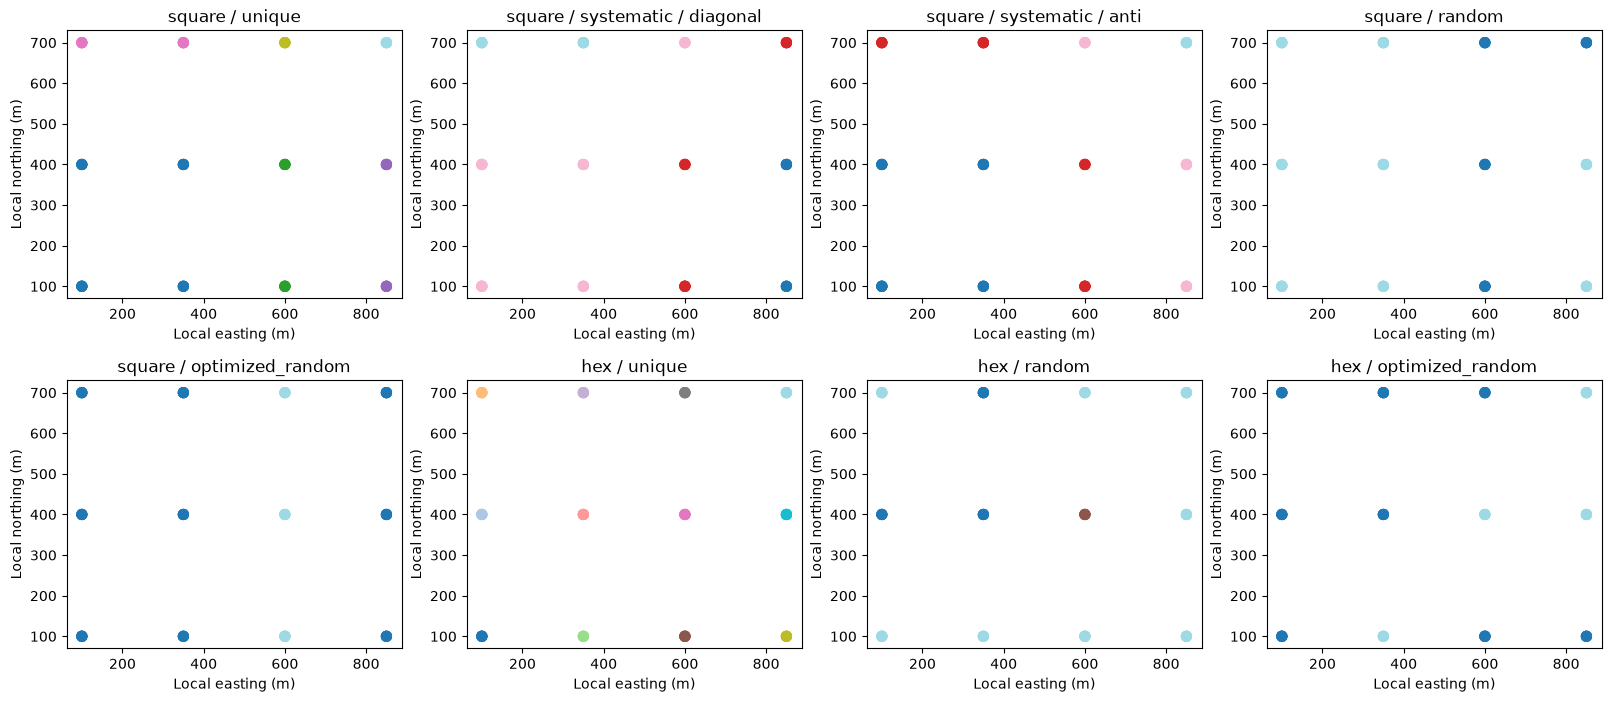

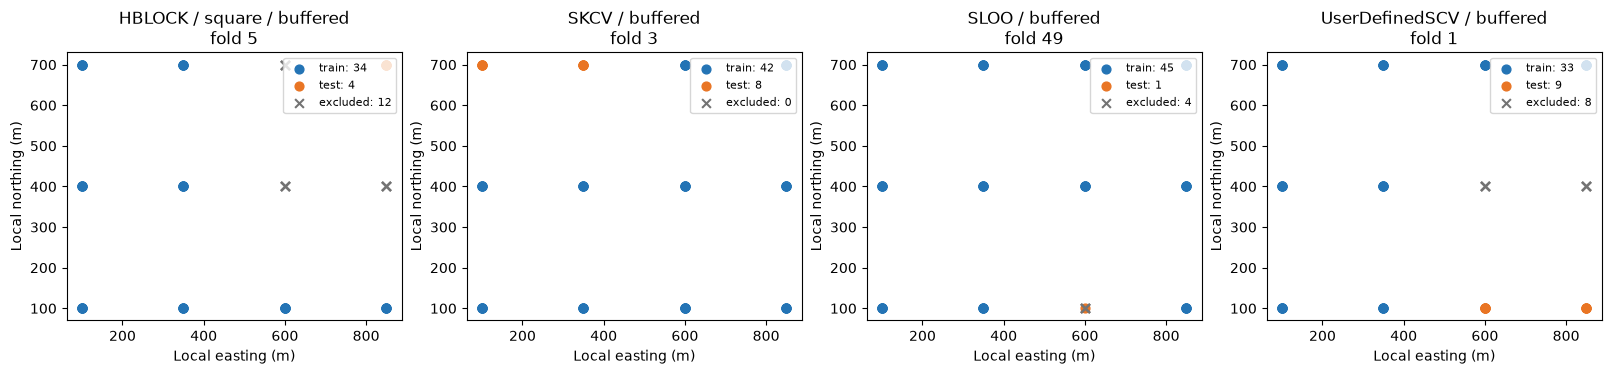

In [8]:
grid_names = [name for name in methods if name.startswith('HBLOCK') and 'buffered' not in name]
fig, axes = plt.subplots(2, 4, figsize=(16, 7), constrained_layout=True)
for ax, name in zip(axes.ravel(), grid_names):
    labels = np.full(len(panel), -1)
    for fold, (_, test) in enumerate(split_cache[name]):
        labels[test] = fold
    ax.scatter(panel.east, panel.north, c=labels, cmap='tab20', s=50)
    ax.set(title=name.replace('HBLOCK / ', ''), xlabel='Local easting (m)', ylabel='Local northing (m)', aspect='equal')
plt.show()

COLORS = {'train': '#2474b5', 'test': '#e97524', 'excluded': '#737373'}
def fold_roles(train, test):
    return {'train': train, 'test': test,
            'excluded': np.setdiff1d(all_indices, np.union1d(train, test))}

buffer_names = ['HBLOCK / square / buffered', 'SKCV / buffered',
                'SLOO / buffered', 'UserDefinedSCV / buffered']
fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
for ax, name in zip(axes, buffer_names):
    # Display the fold with the most actual buffer exclusions.
    fold = int(fold_results.loc[fold_results.method == name].sort_values('excluded').iloc[-1]['fold'])
    for role, indices in fold_roles(*split_cache[name][fold]).items():
        ax.scatter(panel.east.iloc[indices], panel.north.iloc[indices],
                   color=COLORS[role], marker='x' if role == 'excluded' else 'o', s=40, label=f'{role}: {len(indices)}')
    ax.set(title=f'{name}\nfold {fold}', xlabel='Local easting (m)', ylabel='Local northing (m)', aspect='equal')
    ax.legend(fontsize=8)
plt.show()


## 6. 2.5D previews for every configuration

Each panel shows one representative fold. Vertical station traces connect
measurement times; duplicate rows at identical station-time coordinates overlap.
These are time-height scatter plots, not volumetric interpolation. Zero-based
fold IDs match `fold_results`. Use the explorer in the next section to inspect
every other fold, including both repeats of `RepeatedSKCV`.


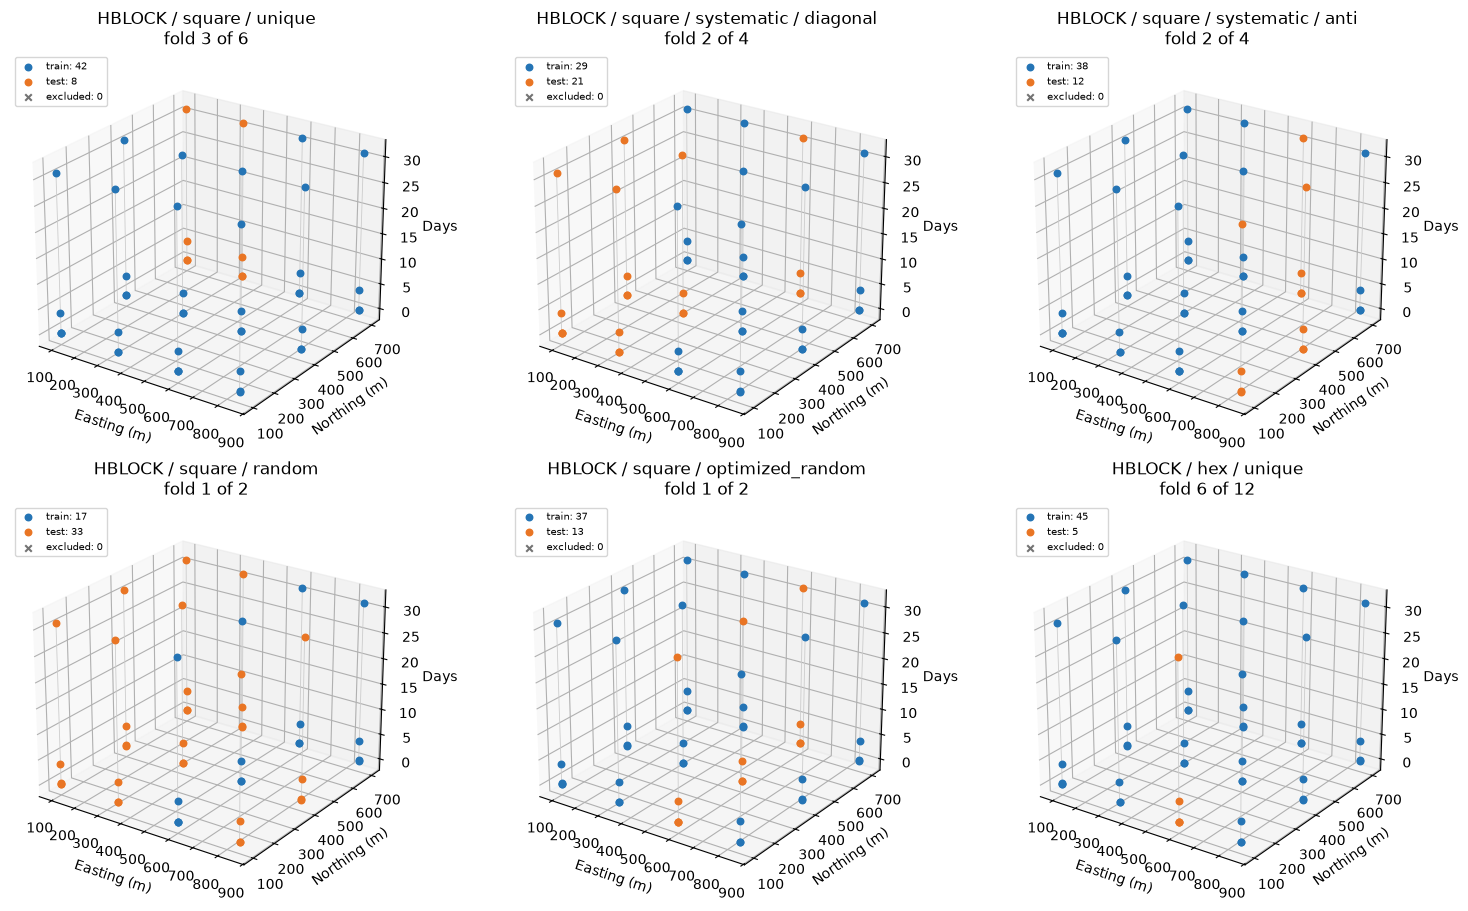

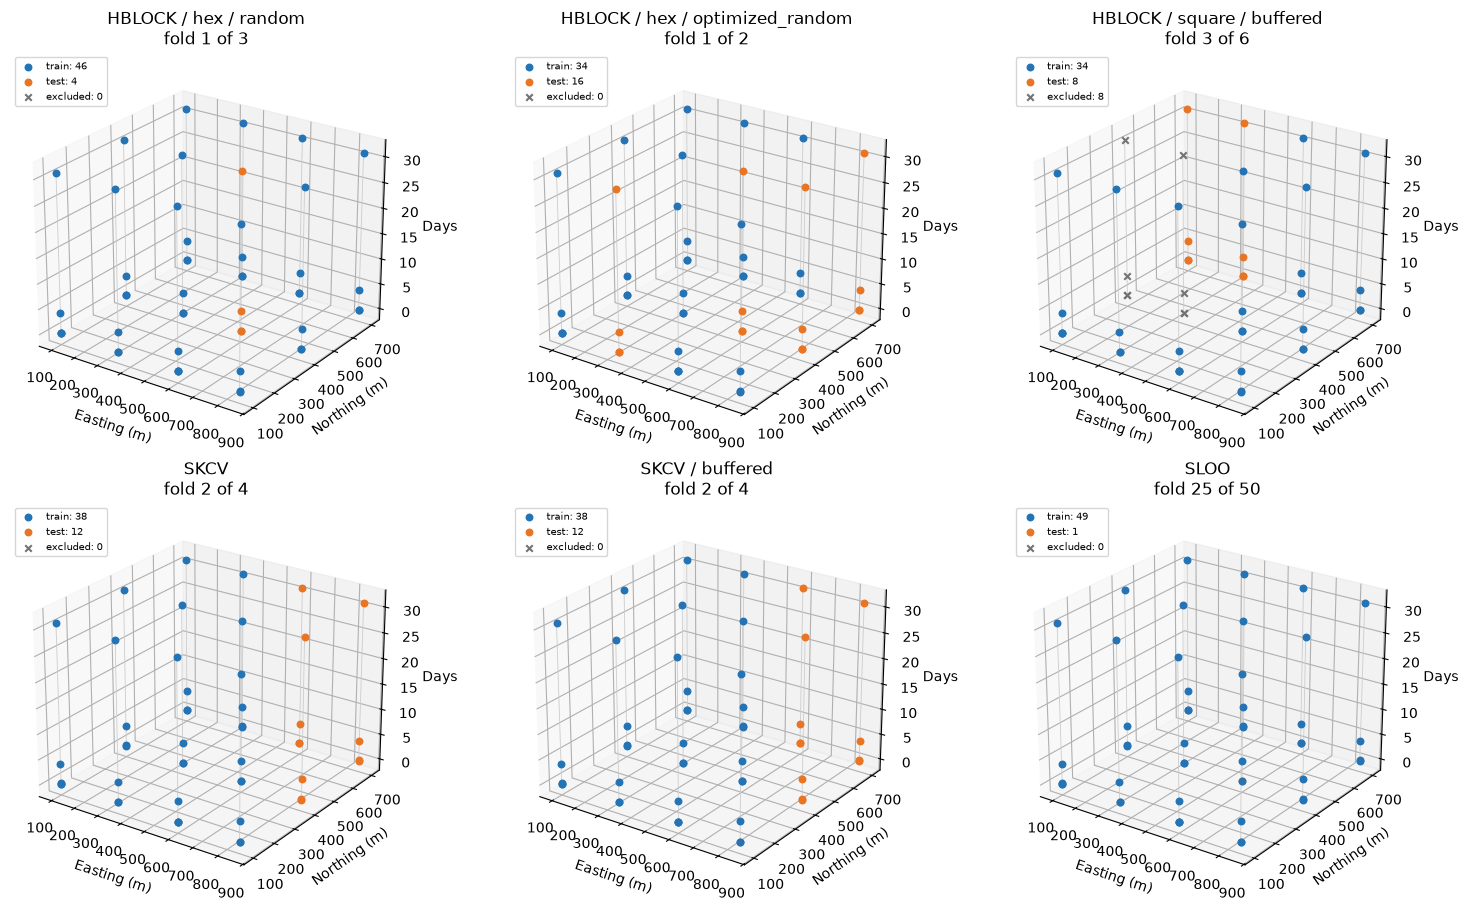

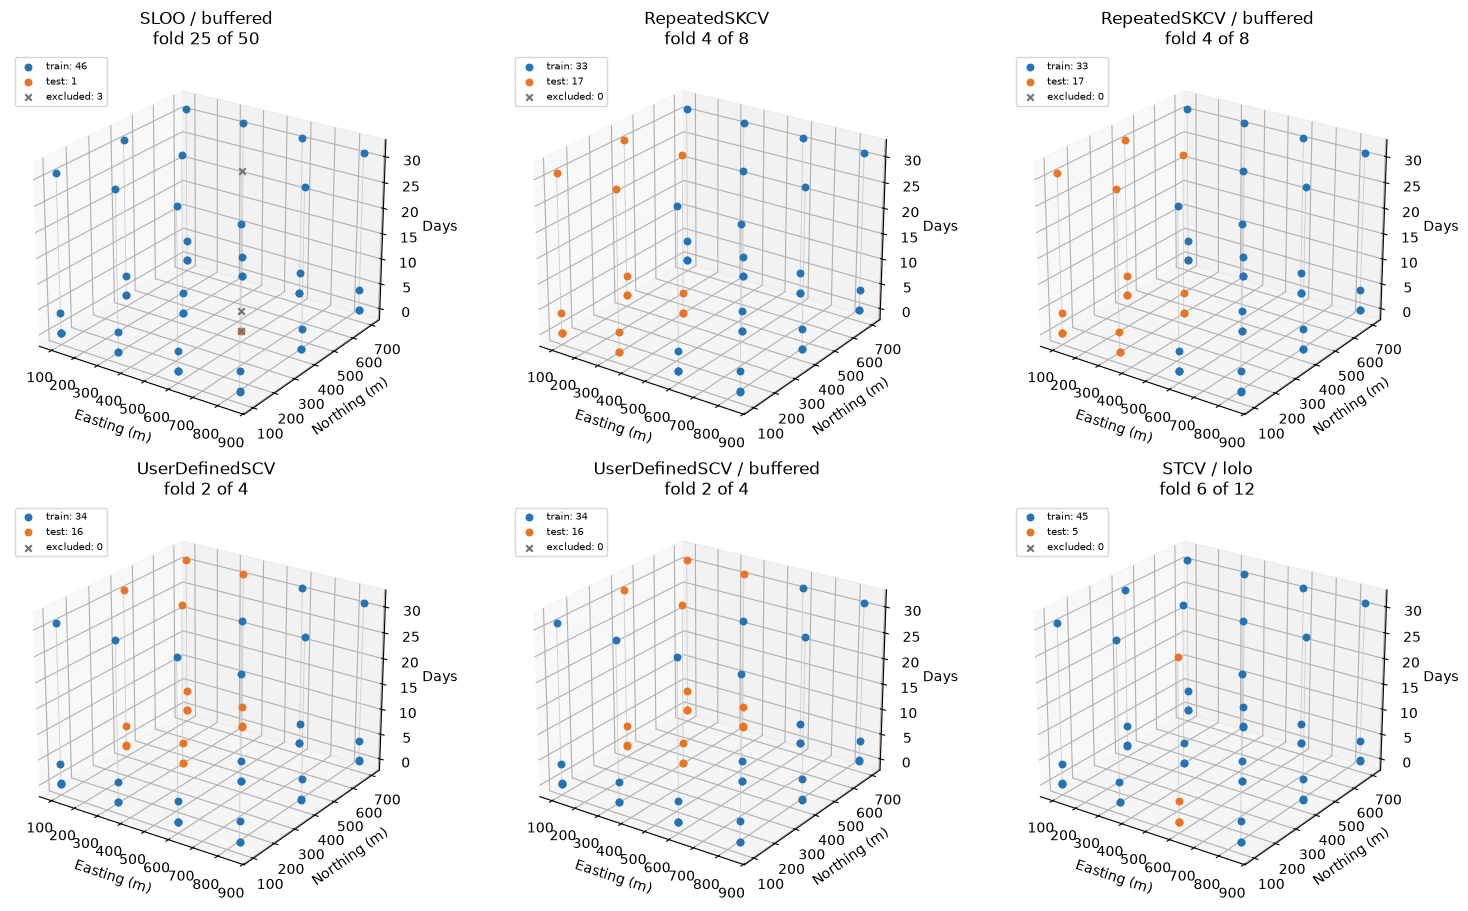

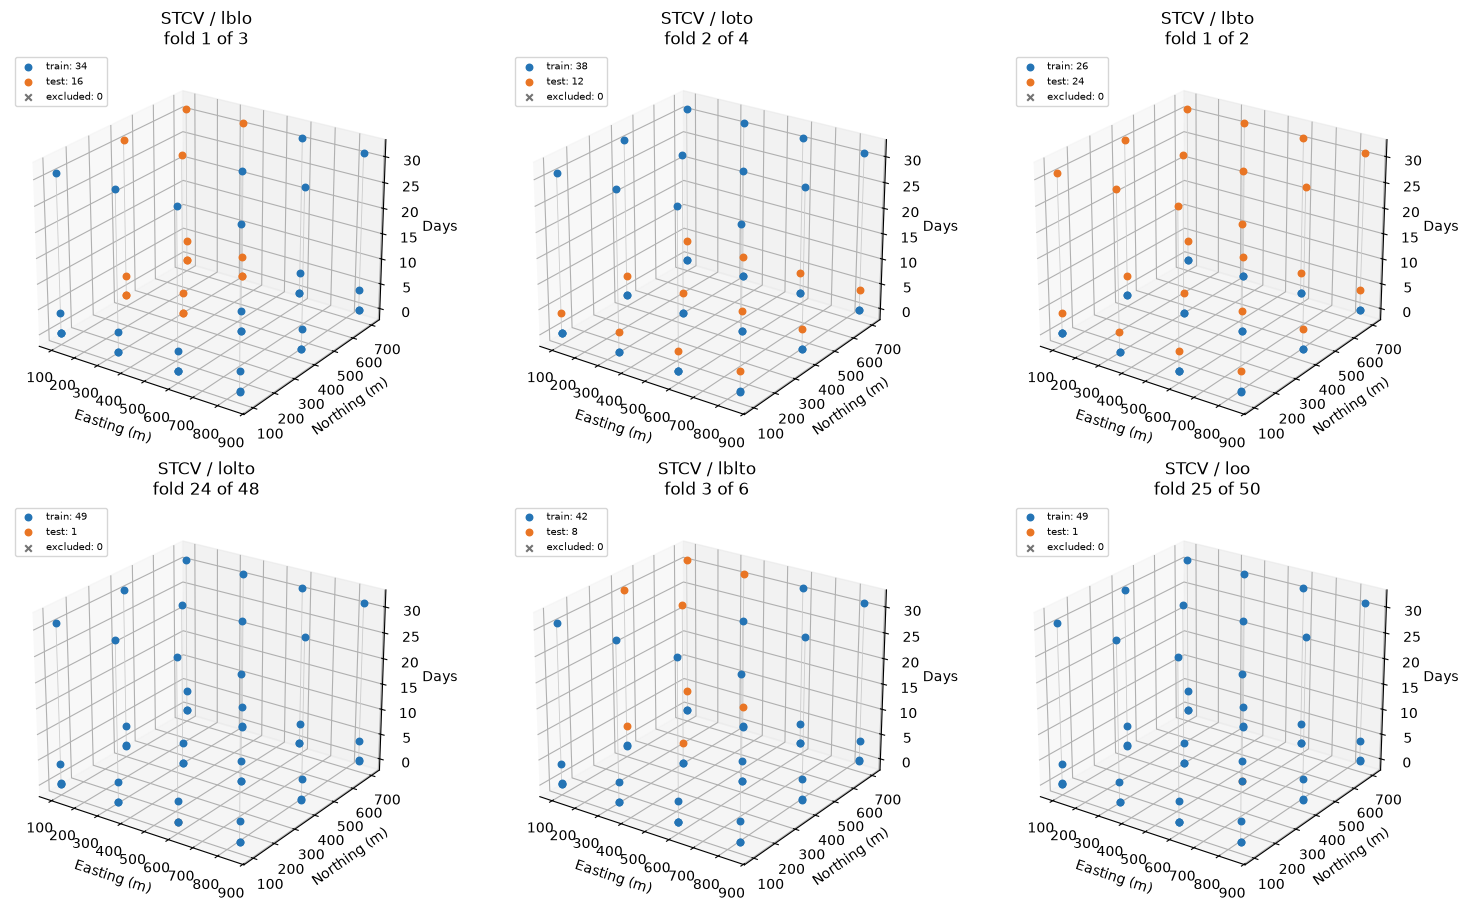

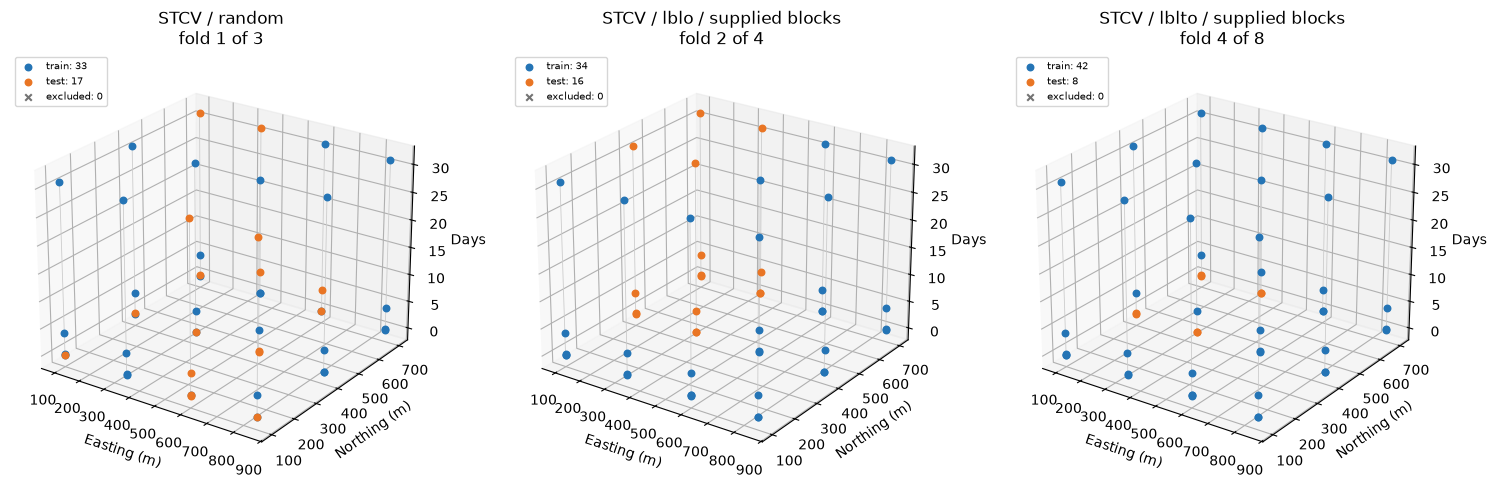

In [9]:
method_names = list(methods)
for start in range(0, len(method_names), 6):
    fig = plt.figure(figsize=(15, 9), layout='constrained')
    for slot, name in enumerate(method_names[start:start + 6], 1):
        ax = fig.add_subplot(2, 3, slot, projection='3d')
        for site in stations.itertuples():
            ax.plot([site.east] * 2, [site.north] * 2, [0, panel.days.max()], color='#cccccc', lw=.6)
        folds = split_cache[name]
        fold = len(folds) // 2
        for role, indices in fold_roles(*folds[fold]).items():
            ax.scatter(panel.east.iloc[indices], panel.north.iloc[indices], panel.days.iloc[indices],
                       c=COLORS[role], marker='x' if role == 'excluded' else 'o',
                       s=22, depthshade=False, label=f'{role}: {len(indices)}')
        ax.set(title=f'{name}\nfold {fold} of {len(folds)}',
               xlabel='Easting (m)', ylabel='Northing (m)', zlabel='Days')
        ax.set_box_aspect((1, 1, .8))
        ax.view_init(elev=24, azim=-55)
        ax.legend(fontsize=7, loc='upper left')
    plt.show()


## 7. Interactive 2.5D explorer: all methods, all folds

Choose a configuration, then drag the fold slider or use Previous/Next. Hover
a point for its observation index, station, time, and role. The SVG is a fixed
oblique projection of the same east/north/time coordinates used above; the
vertical axis retains actual elapsed days. It embeds all cached split indices
and needs no network requests or extra widget packages.

Run this cell in a trusted Jupyter notebook to enable its JavaScript controls.
Static outputs above remain available in viewers that disable JavaScript.


In [10]:
explorer_data = {
    'points': [{'east': float(row.east), 'north': float(row.north), 'days': float(row.days),
                'station': int(row.station), 'time': str(row.timestamp)} for row in panel.itertuples()],
    'methods': [{'name': name, 'folds': [{'train': train.tolist(), 'test': test.tolist()}
                 for train, test in folds]} for name, folds in split_cache.items()],
    'colors': COLORS,
}
explorer_template = r"""
<div id="spacv-v2-explorer" style="font-family:system-ui;padding:16px;background:#f8fafc;color:#172033;border:1px solid #cbd5e1;border-radius:8px">
  <label>Method <select data-method style="max-width:100%;padding:5px"></select></label>
  <div style="display:flex;gap:12px;align-items:center;margin:14px 0">
    <button data-prev>Previous</button><label>Fold <input data-fold type="range" min="0" value="0" aria-label="Fold index"></label>
    <button data-next>Next</button><span data-count></span>
  </div>
  <div data-status aria-live="polite"></div>
  <svg data-plot viewBox="0 0 900 590" role="img" aria-label="Spatial cross-validation time-height view" style="width:100%;max-width:1000px;background:white;margin-top:12px"></svg>
</div>
<script>
(() => {
  const root = document.getElementById('spacv-v2-explorer');
  const data = __DATA__;
  const select = root.querySelector('[data-method]'), slider = root.querySelector('[data-fold]');
  const svg = root.querySelector('[data-plot]'), ns = 'http://www.w3.org/2000/svg';
  function node(tag, attrs, text) {
    const el = document.createElementNS(ns, tag);
    Object.entries(attrs).forEach(([k, v]) => el.setAttribute(k, v));
    if (text !== undefined) el.textContent = text;
    svg.appendChild(el); return el;
  }
  const maxDays = Math.max(...data.points.map(p => p.days));
  function project(east, north, days) {
    const x = (east - 100) / 750, y = (north - 100) / 600, z = days / maxDays;
    return [300 + 390*x - 220*y, 520 - 110*x - 120*y - 270*z];
  }
  function line(a, b, color, width=1) {
    node('line', {x1:a[0], y1:a[1], x2:b[0], y2:b[1], stroke:color, 'stroke-width':width});
  }
  data.methods.forEach((m, i) => {
    const option = document.createElement('option'); option.value = i; option.textContent = m.name; select.appendChild(option);
  });
  function draw() {
    const m = data.methods[Number(select.value)], f = Number(slider.value), fold = m.folds[f];
    const train = new Set(fold.train), test = new Set(fold.test);
    const excluded = data.points.length - train.size - test.size;
    root.querySelector('[data-count]').textContent = `${f} / ${m.folds.length - 1}`;
    root.querySelector('[data-status]').textContent = `Train: ${train.size} (blue) · Test: ${test.size} (orange) · Excluded: ${excluded} (grey crosses)`;
    root.querySelector('[data-prev]').disabled = f === 0;
    root.querySelector('[data-next]').disabled = f === m.folds.length - 1;
    svg.replaceChildren();
    const origin = project(100, 100, 0);
    for (const [east,north,days,label] of [[850,100,0,'Easting (m)'],[100,700,0,'Northing (m)'],[100,100,maxDays,'Elapsed days']]) {
      const end = project(east,north,days); line(origin,end,'#475569',2);
      node('text', {x:end[0]+8,y:end[1]-8,fill:'#172033','font-size':14}, label);
    }
    for (const d of [0, 5, 15, maxDays]) {
      const p = project(100,100,d);
      node('text',{x:p[0]-12,y:p[1]+4,'text-anchor':'end',fill:'#475569','font-size':12}, d.toFixed(0));
    }
    for (const e of [100,350,600,850]) {
      const p = project(e,100,0); node('text',{x:p[0],y:p[1]+18,fill:'#475569','font-size':12},e);
    }
    for (const n of [100,400,700]) {
      const p = project(100,n,0); node('text',{x:p[0]-12,y:p[1]+18,fill:'#475569','font-size':12},n);
    }
    const seen = new Set();
    data.points.forEach(p => {
      if (!seen.has(p.station)) {
        line(project(p.east,p.north,0),project(p.east,p.north,maxDays),'#dce3eb'); seen.add(p.station);
      }
    });
    // Draw higher/northerly points first for a stable oblique projection.
    const order = data.points.map((p,i) => i).sort((a,b) => data.points[b].north-data.points[a].north || data.points[b].days-data.points[a].days);
    order.forEach(i => {
      const p = data.points[i], role = test.has(i) ? 'test' : train.has(i) ? 'train' : 'excluded';
      const [x,y] = project(p.east,p.north,p.days), color = data.colors[role];
      const mark = role === 'excluded'
        ? node('path',{d:`M ${x-4} ${y-4} L ${x+4} ${y+4} M ${x-4} ${y+4} L ${x+4} ${y-4}`,stroke:color,'stroke-width':2,fill:'none'})
        : node('circle',{cx:x,cy:y,r:role==='test'?6:4,fill:color,stroke:'white','stroke-width':.8});
      const title = document.createElementNS(ns,'title');
      title.textContent = `Row ${i} · Station ${p.station} · ${p.time} · ${role}`; mark.appendChild(title);
    });
  }
  select.addEventListener('change',() => { slider.max = data.methods[Number(select.value)].folds.length-1; slider.value=0; draw(); });
  slider.addEventListener('input',draw);
  root.querySelector('[data-prev]').addEventListener('click',() => {slider.value = Number(slider.value)-1;draw();});
  root.querySelector('[data-next]').addEventListener('click',() => {slider.value = Number(slider.value)+1;draw();});
  slider.max = data.methods[0].folds.length-1; draw();
})();
</script>
"""
display(HTML(explorer_template.replace('__DATA__', json.dumps(explorer_data))))


## 8. scikit-learn integration and parameter search

Either pass cached `(train, test)` splits to `cv`, or pass a splitter object and
supply the spatial/spatiotemporal data through `groups`. A pipeline keeps feature
scaling inside training folds. The example checks that scikit-learn reproduces
our manual per-fold MAE. A grid search demonstrates the direct `groups` interface;
its tuning score is not an independent final performance estimate.


In [11]:
name = 'STCV / lblto'
scores = -cross_val_score(model, X, y, cv=split_cache[name],
                          scoring='neg_mean_absolute_error', error_score='raise')
manual = fold_results.loc[fold_results.method == name, 'MAE'].to_numpy()
np.testing.assert_allclose(scores, manual)

group_cv = methods[name]
group_scores = -cross_val_score(model, X, y, cv=group_cv, groups=panel,
                                scoring='neg_mean_absolute_error', error_score='raise')
np.testing.assert_allclose(group_scores, manual)

search = GridSearchCV(model, {'ridge__alpha': [.1, 1., 10.]}, cv=group_cv,
                      scoring='neg_mean_absolute_error', error_score='raise')
search.fit(X, y, groups=panel)
print('Best parameters:', search.best_params_)
display(pd.DataFrame(search.cv_results_)[['param_ridge__alpha', 'mean_test_score', 'rank_test_score']])


Best parameters: {'ridge__alpha': 0.1}


,param_ridge__alpha,mean_test_score,rank_test_score
0,0.1,-0.856134,1
1,1.0,-0.875690,2
2,10.0,-1.181228,3


## 9. Polygon observations (lattice SKCV)

The same splitter also accepts polygon observations. This small example buffers
station footprints and iterates every fold. STCV uses polygon centroids to identify
and cluster locations; the geometric SKCV buffer follows the polygon union.


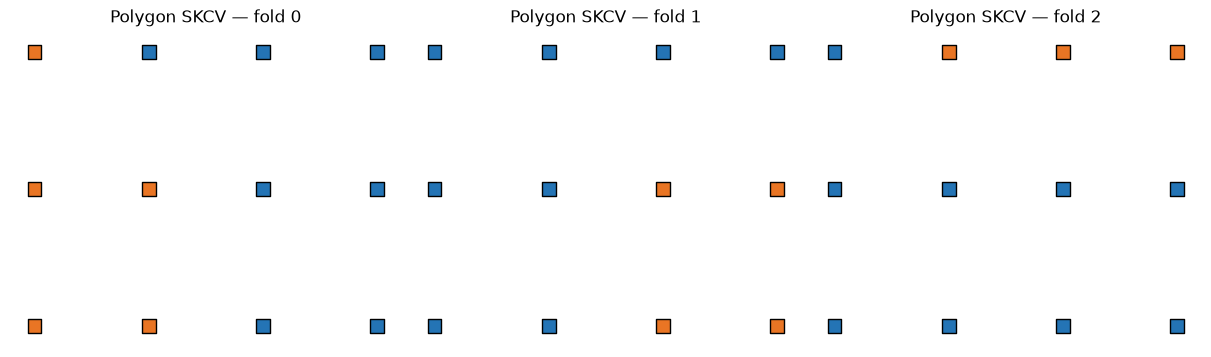

In [12]:
lattice = gpd.GeoDataFrame({'station': stations.station}, geometry=[
    box(500000 + e - 15, 5700000 + n - 15, 500000 + e + 15, 5700000 + n + 15)
    for e, n in zip(stations.east, stations.north)
], crs=panel.crs)
lattice_cv = spacv.SKCV(n_splits=3, buffer_radius=60, random_state=SEED)
lattice_folds = list(lattice_cv.split(lattice))
visits = np.zeros(len(lattice), dtype=int)
fig, axes = plt.subplots(1, len(lattice_folds), figsize=(12, 4), constrained_layout=True)
for fold, (ax, (train, test)) in enumerate(zip(axes, lattice_folds)):
    assert len(train) and len(test) and not np.intersect1d(train, test).size
    visits[test] += 1
    excluded = np.setdiff1d(np.arange(len(lattice)), np.union1d(train, test))
    for role, indices in {'train': train, 'test': test, 'excluded': excluded}.items():
        if len(indices):
            lattice.iloc[indices].plot(ax=ax, color=COLORS[role], edgecolor='black')
    ax.set_title(f'Polygon SKCV — fold {fold}')
    ax.set_axis_off()
np.testing.assert_array_equal(visits, np.ones(len(lattice), dtype=int))
plt.show()


## 10. Reuse this workflow on your data

1. Prepare a GeoDataFrame with a suitable projected CRS, numeric predictors,
   a target, and a numeric or datetime temporal column if needed.
2. Select a split unit that matches the intended prediction task; select block
   sizes and buffers in coordinate units. Ensure every fold leaves training data.
3. Materialize `list(cv.split(frame))`, audit coverage and excluded rows, and use
   those cached splits for consistent visualization and scoring.
4. Pass feature columns to the model and the GeoDataFrame through `groups`, or
   supply the precomputed split iterable. Keep preprocessing inside a pipeline.

For a single `STCV` partition, `cv.fold_labels(frame)` returns fold labels in the
original row order, and `cv.get_n_splits(frame)` counts observed folds. Repeated
CV requires a separate assignment per repeat. Temporal holdouts here are missing
slice/cell validation, so use a forecasting-specific splitter when future-only
training is required.

This tour covers the exported CV API. The internal `compute_gcv` helper is not
exported and currently references an unavailable `spreg` import; it is not a
runnable supported splitter. Spatial diagnostic utilities in
`spacv.visualisation` (variograms and area of applicability) are separate from
fold generation.
